# 🎵 Project 4: Music Pattern Analysis
**Goal:** Discover hidden clusters in songs using audio features — then build a recommender.

**Recommended Datasets:**
- **DataSet:** [Spotify 1.2M+ Songs (Kaggle)](https://www.kaggle.com/datasets/rodolfofigueroa/spotify-12m-songs) — 1.2M tracks ⭐



In [11]:
# !pip install pandas numpy scikit-learn matplotlib seaborn plotly spotipy


## 1. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":0.3})
print("✅ Imports successful")


✅ Imports successful


## 2. Load Spotify Data
> **Live API option:**
> ```python
> import spotipy
> from spotipy.oauth2 import SpotifyClientCredentials
> sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
>     client_id="YOUR_CLIENT_ID", client_secret="YOUR_SECRET"))
> results = sp.playlist_tracks("PLAYLIST_URI")
> track_ids = [item["track"]["id"] for item in results["items"]]
> features = sp.audio_features(track_ids)
> df = pd.DataFrame(features)
> ```


In [17]:
AUDIO_FEATURES = ["danceability","energy","loudness","speechiness",
                   "acousticness","instrumentalness","liveness","valence","tempo"]

def make_music_data(n=2000, seed=42):
    """Synthetic data mirroring Spotify audio features schema."""
    rng = np.random.default_rng(seed)
    
    genres = {
        "EDM":          dict(danceability=(0.75,0.1), energy=(0.85,0.08), tempo=(128,10),
                             acousticness=(0.05,0.05), valence=(0.65,0.15)),
        "Pop":          dict(danceability=(0.65,0.12), energy=(0.65,0.12), tempo=(110,15),
                             acousticness=(0.2,0.15),  valence=(0.55,0.18)),
        "Acoustic/Folk":dict(danceability=(0.45,0.12), energy=(0.35,0.12), tempo=(90,15),
                             acousticness=(0.75,0.12),  valence=(0.45,0.18)),
        "Hip-Hop":      dict(danceability=(0.78,0.1),  energy=(0.60,0.12), tempo=(95,15),
                             acousticness=(0.12,0.1),   valence=(0.42,0.18)),
        "Classical":    dict(danceability=(0.25,0.1),  energy=(0.25,0.12), tempo=(85,25),
                             acousticness=(0.88,0.08),  valence=(0.35,0.18)),
    }
    rows = []
    per_genre = n // len(genres)
    for genre, params in genres.items():
        for _ in range(per_genre):
            row = {"genre": genre,
                   "loudness":         rng.uniform(-20,-3),
                   "speechiness":      rng.exponential(0.05),
                   "instrumentalness": rng.beta(0.3,2),
                   "liveness":         rng.uniform(0.05,0.5)}
            for feat,(mu,sig) in params.items():
                row[feat] = np.clip(rng.normal(mu,sig), 0, 1 if feat!="tempo" else 200)
            rows.append(row)
    
    df = pd.DataFrame(rows)
    track_words = ["Dawn","Echo","Storm","Neon","Drift","Pulse","Haze","Glow","Wave","Fade"]
    df["track_name"] = [f"{rng.choice(track_words)} {i+1}" for i in range(len(df))]
    return df.reset_index(drop=True)

df = pd.read_csv("tracks_features.csv")
print(f"Shape : {df.shape}")
df[AUDIO_FEATURES].describe().round(3)
print("Your columns:", df.columns.tolist())


Shape : (1204025, 24)
Your columns: ['id', 'name', 'album', 'album_id', 'artists', 'artist_ids', 'track_number', 'disc_number', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'year', 'release_date']


## 3. Exploratory Data Analysis

       danceability       energy     loudness  speechiness  acousticness  \
count   1204025.000  1204025.000  1204025.000  1204025.000   1204025.000   
mean          0.493        0.510      -11.809        0.084         0.447   
std           0.190        0.295        6.982        0.116         0.385   
min           0.000        0.000      -60.000        0.000         0.000   
25%           0.356        0.252      -15.254        0.035         0.038   
50%           0.501        0.524       -9.791        0.045         0.389   
75%           0.633        0.766       -6.717        0.072         0.861   
max           1.000        1.000        7.234        0.969         0.996   

       instrumentalness     liveness      valence        tempo  
count       1204025.000  1204025.000  1204025.000  1204025.000  
mean              0.283        0.202        0.428      117.634  
std               0.376        0.180        0.270       30.937  
min               0.000        0.000        0.000      

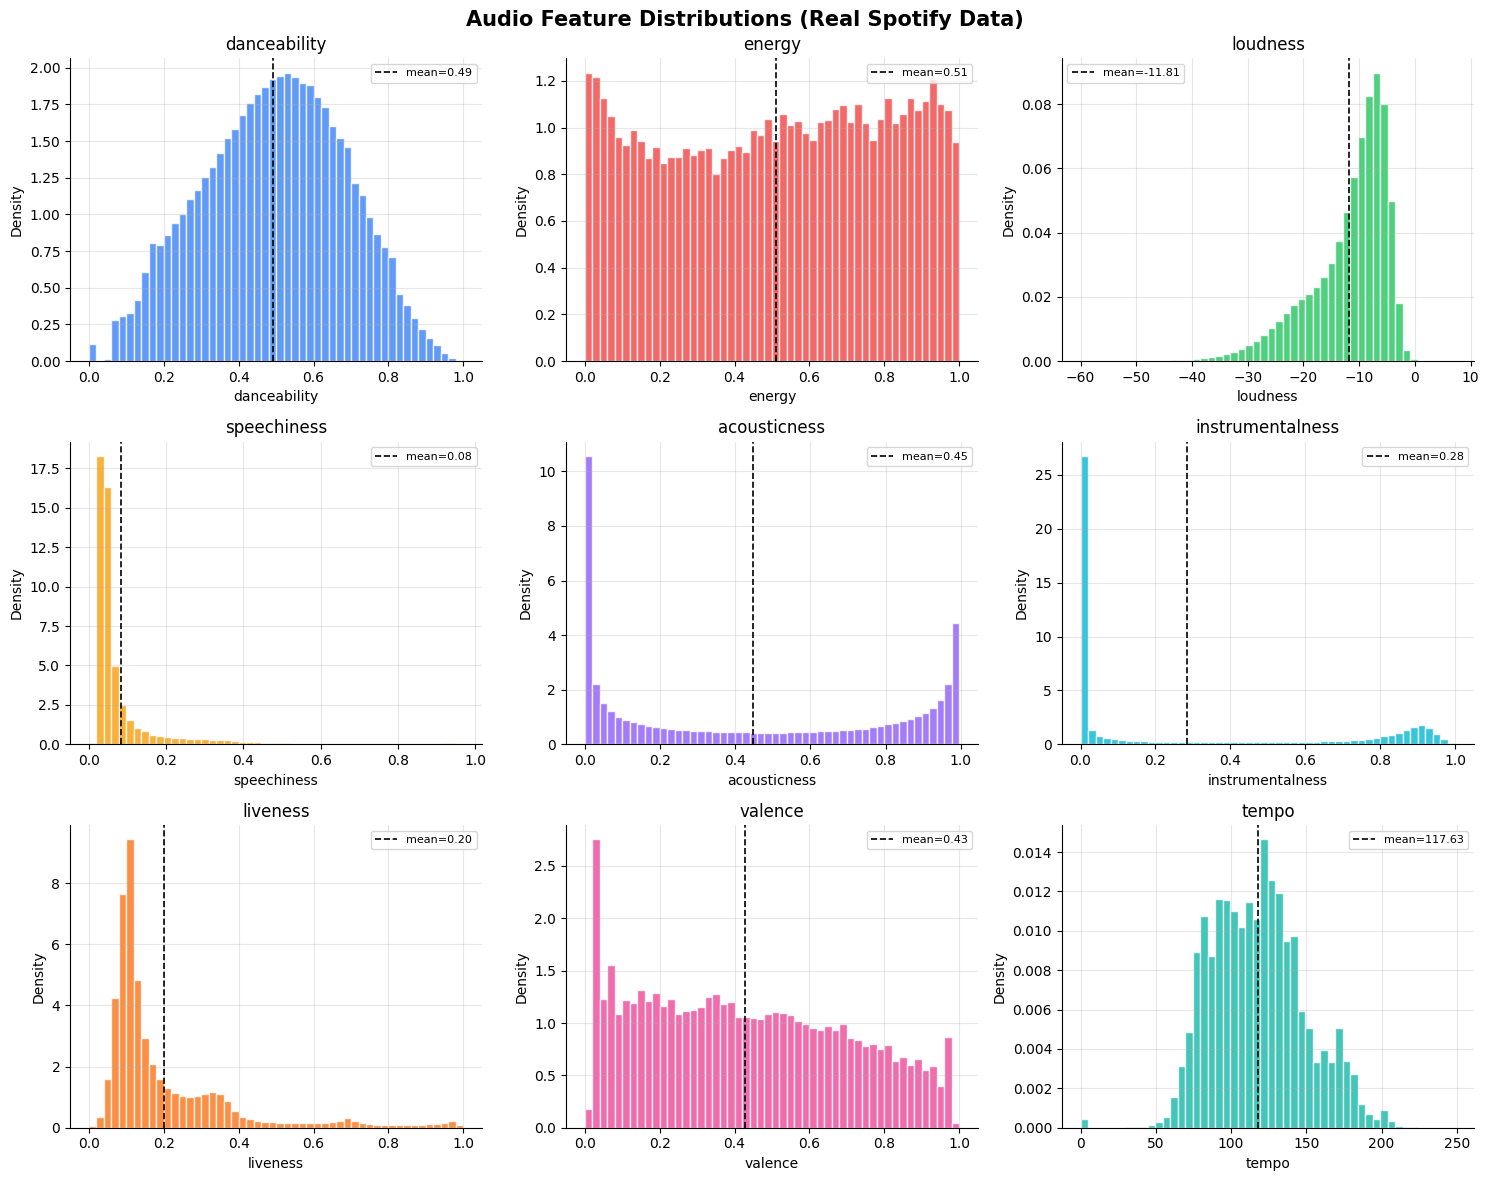

In [18]:
print(df[AUDIO_FEATURES].describe().round(3))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Audio Feature Distributions (Real Spotify Data)", fontsize=15, fontweight="bold")

colors = ["#3b82f6", "#ef4444", "#22c55e", "#f59e0b", "#8b5cf6",
          "#06b6d4", "#f97316", "#ec4899", "#14b8a6"]

for ax, feat, color in zip(axes.flatten(), AUDIO_FEATURES, colors):
    ax.hist(df[feat].dropna(), bins=50, color=color, alpha=0.8,
            density=True, edgecolor="white")
    ax.set(title=feat, xlabel=feat, ylabel="Density")
    ax.axvline(df[feat].mean(), color="black", ls="--", lw=1.2,
               label=f"mean={df[feat].mean():.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



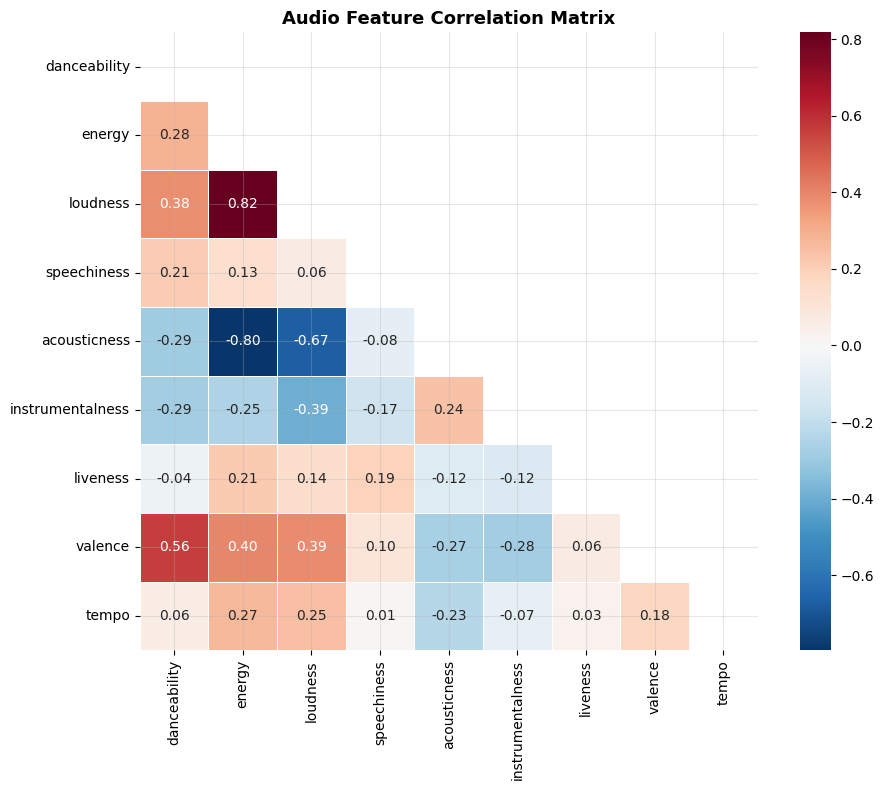

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[AUDIO_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title("Audio Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Normalize Features

In [24]:
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(df[AUDIO_FEATURES])
X_df     = pd.DataFrame(X_scaled, columns=AUDIO_FEATURES)

print("✅ Features normalized to [0, 1]")
X_df.describe().round(3)


✅ Features normalized to [0, 1]


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1204025.000,1204025.000,1204025.000,1204025.000,1204025.000,1204025.000,1204025.000,1204025.000,1204025.000
mean,0.493,0.510,0.717,0.087,0.449,0.283,0.202,0.428,0.473
std,0.190,0.295,0.104,0.120,0.387,0.376,0.180,0.270,0.124
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.356,0.252,0.666,0.036,0.038,0.000,0.097,0.191,0.378
50%,0.501,0.524,0.747,0.046,0.391,0.008,0.125,0.403,0.469
75%,0.633,0.766,0.793,0.075,0.864,0.719,0.245,0.644,0.551
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 5. Find Optimal Number of Clusters

Working with 3,000 rows
X_scaled shape: (3000, 9)
  K=2  Silhouette=0.340  DB=1.260
  K=3  Silhouette=0.313  DB=1.201
  K=4  Silhouette=0.326  DB=1.173
  K=5  Silhouette=0.255  DB=1.381
  K=6  Silhouette=0.236  DB=1.440
  K=7  Silhouette=0.254  DB=1.375
  K=8  Silhouette=0.239  DB=1.416


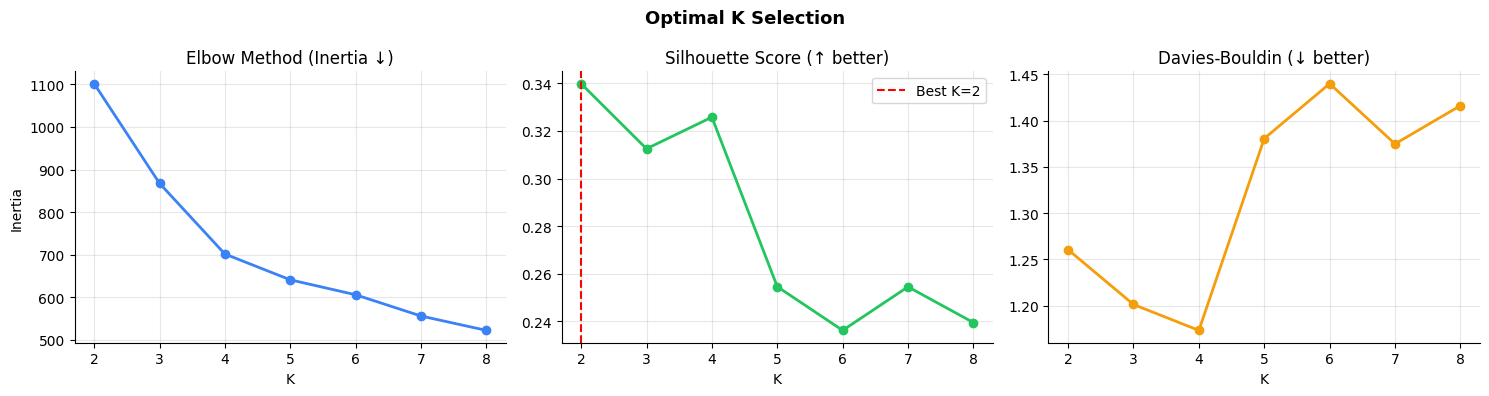


✅ Best K = 2


In [28]:
# ── STEP 1: Sample FIRST (3000 rows) ─────────────────────────
df = df.sample(3_000, random_state=42).reset_index(drop=True)
print(f"Working with {len(df):,} rows")

# ── STEP 2: Scale AFTER sampling ─────────────────────────────
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(df[AUDIO_FEATURES])
print(f"X_scaled shape: {X_scaled.shape}")  # should say (3000, 9)

# ── STEP 3: Find best K (now fast) ───────────────────────────
inertia, sil_scores, db_scores = [], [], []
K_RANGE = range(2, 9)   # reduced from 11 to 9, saves 2 iterations

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=3)  # n_init=3 not 10
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=1000))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  K={k}  Silhouette={sil_scores[-1]:.3f}  DB={db_scores[-1]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Optimal K Selection", fontsize=13, fontweight="bold")

axes[0].plot(K_RANGE, inertia, marker="o", color="#3b82f6", lw=2)
axes[0].set(title="Elbow Method (Inertia ↓)", xlabel="K", ylabel="Inertia")

best_k = list(K_RANGE)[np.argmax(sil_scores)]
axes[1].plot(K_RANGE, sil_scores, marker="o", color="#22c55e", lw=2)
axes[1].axvline(best_k, color="red", ls="--", label=f"Best K={best_k}")
axes[1].set(title="Silhouette Score (↑ better)", xlabel="K")
axes[1].legend()

axes[2].plot(K_RANGE, db_scores, marker="o", color="#f59e0b", lw=2)
axes[2].set(title="Davies-Bouldin (↓ better)", xlabel="K")

plt.tight_layout()
plt.show()
print(f"\n✅ Best K = {best_k}")

## 6. K-Means Clustering

In [30]:
K = best_k
km_final     = KMeans(n_clusters=K, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)

# Auto-label each cluster based on its dominant audio traits
cluster_profile = df.groupby("cluster")[AUDIO_FEATURES].mean()

def auto_label(row):
    if row["energy"] > 0.75 and row["danceability"] > 0.7:
        return "High-Energy Dance"
    elif row["acousticness"] > 0.6 and row["energy"] < 0.4:
        return "Chill / Acoustic"
    elif row["instrumentalness"] > 0.4:
        return "Instrumental"
    elif row["valence"] > 0.7 and row["danceability"] > 0.6:
        return "Happy / Upbeat"
    elif row["speechiness"] > 0.15:
        return "Spoken / Hip-Hop"
    else:
        return f"Cluster {int(row.name)}"

cluster_labels = {i: auto_label(cluster_profile.loc[i]) for i in cluster_profile.index}
df["vibe"]     = df["cluster"].map(cluster_labels)

print("Cluster sizes:")
print(df["vibe"].value_counts().to_string())
print("\nCluster Profiles (mean values):")
print(cluster_profile.round(3).to_string())


Cluster sizes:
vibe
Cluster 0           1740
Chill / Acoustic    1260

Cluster Profiles (mean values):
         danceability  energy  loudness  speechiness  acousticness  instrumentalness  liveness  valence    tempo
cluster                                                                                                         
0               0.545   0.706    -7.836        0.094         0.164             0.179     0.231    0.518  123.748
1               0.408   0.237   -17.506        0.067         0.842             0.448     0.168    0.298  108.970


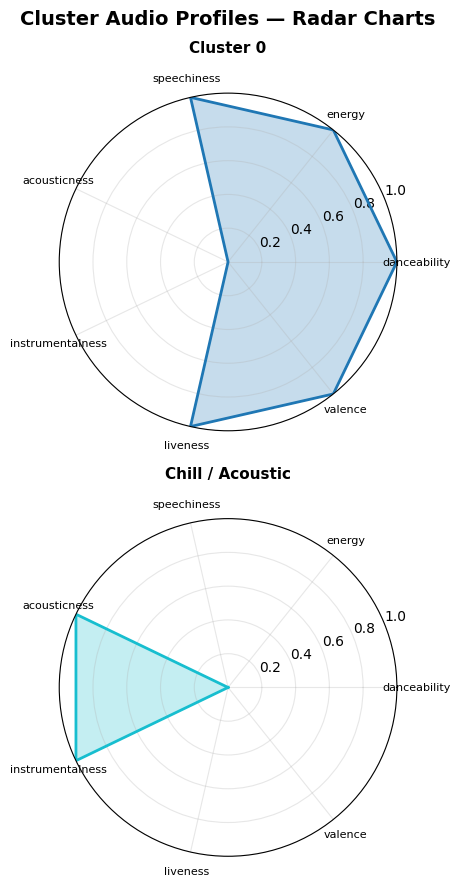

In [34]:
# Radar chart per cluster
RADAR_FEATURES = ["danceability","energy","speechiness",
                  "acousticness","instrumentalness","liveness","valence"]

angles = np.linspace(0, 2*np.pi, len(RADAR_FEATURES), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, (K+1)//2, figsize=(5*K, 9),
                         subplot_kw=dict(polar=True))
fig.suptitle("Cluster Audio Profiles — Radar Charts", fontsize=14, fontweight="bold")

scaler_radar = MinMaxScaler()
radar_data   = pd.DataFrame(
    scaler_radar.fit_transform(cluster_profile[RADAR_FEATURES]),
    columns=RADAR_FEATURES,
    index=cluster_profile.index
)

colors = plt.cm.tab10(np.linspace(0, 0.9, K))
for i, ax in enumerate(axes.flatten()[:K]):
    vals = radar_data.iloc[i].tolist() + [radar_data.iloc[i].tolist()[0]]
    ax.plot(angles, vals, color=colors[i], lw=2)
    ax.fill(angles, vals, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_FEATURES, size=8)
    vibe_name = cluster_labels.get(i, f"Cluster {i}")
    ax.set_title(vibe_name, fontsize=11, fontweight="bold", pad=15)
    ax.set_ylim(0, 1)

for ax in axes.flatten()[K:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()



## 7. Dimensionality Reduction & Visualization

PCA explained variance: 69.0%
Running t-SNE (30–60 seconds)...


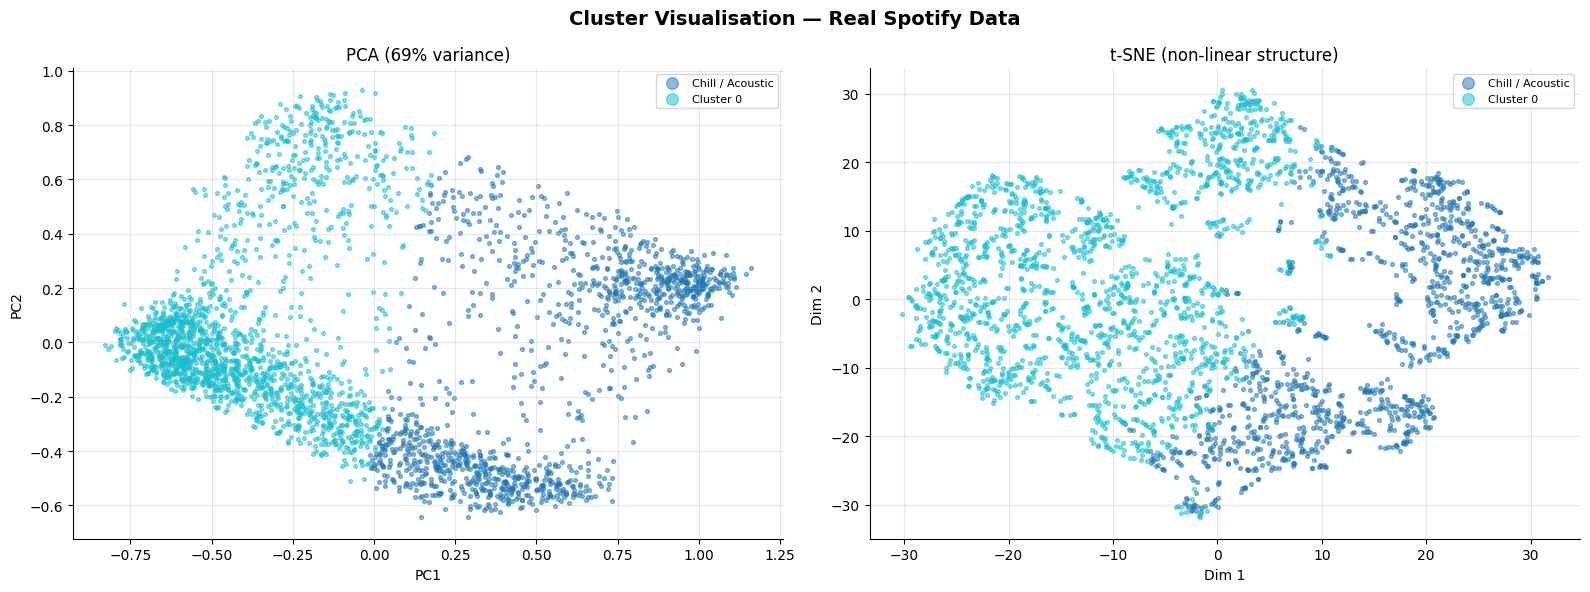

In [33]:
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

print("Running t-SNE (30–60 seconds)...")
tsne   = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=500)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Cluster Visualisation — Real Spotify Data", fontsize=14, fontweight="bold")

colors = plt.cm.tab10(np.linspace(0, 0.9, K))
vibes  = sorted(df["vibe"].unique())
color_map = {v: colors[i] for i, v in enumerate(vibes)}

for vibe in vibes:
    mask = df["vibe"] == vibe
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[color_map[vibe]], s=8, alpha=0.5, label=vibe)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=[color_map[vibe]], s=8, alpha=0.5, label=vibe)

axes[0].set(title=f"PCA ({pca.explained_variance_ratio_.sum()*100:.0f}% variance)",
            xlabel="PC1", ylabel="PC2")
axes[0].legend(markerscale=3, fontsize=8)

axes[1].set(title="t-SNE (non-linear structure)", xlabel="Dim 1", ylabel="Dim 2")
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

## 8. Song Recommender (Cosine Similarity)

In [ ]:
def recommend(track_name, n=5):
    """Find the n most similar songs to any track in the dataset."""
    # dataset uses 'name' (and likely 'artists') instead of 'track_name'/'artist'
    name_col = "name" if "name" in df.columns else "track_name"
    artist_col = "artist" if "artist" in df.columns else ("artists" if "artists" in df.columns else None)

    names = df[name_col].astype(str)
    matches = df[names.str.lower().str.contains(track_name.lower(), na=False)]
    if matches.empty:
        print(f"❌ No track found matching '{track_name}'")
        print("Try one of these:")
        print(df[name_col].sample(5).tolist())
        return

    idx  = matches.index[0]
    sims = cosine_similarity(X_scaled[idx].reshape(1, -1), X_scaled)[0]
    sims[idx] = -1   # exclude self

    top_idx = np.argsort(sims)[-n:][::-1]
    cols = [name_col]
    if artist_col:
        cols.append(artist_col)
    cols += ["vibe"] + AUDIO_FEATURES[:4]
    recs = df.iloc[top_idx][cols].copy()
    recs["similarity"] = sims[top_idx].round(4)

    query = df.iloc[idx]
    artist_str = ""
    if artist_col:
        art = query.get(artist_col, "")
        if isinstance(art, list):
            artist_str = art[0] if art else ""
        else:
            artist_str = str(art)

    print(f"\n🎵 Query : '{query[name_col]}'" + (f" by {artist_str}" if artist_str else "") + f"  [{query.get('vibe','')}]")
    print(f"\nTop {n} similar songs:")
    print(recs.to_string(index=False))
    return recs

# Try with a real song name from your dataset
sample_track = df["name"].iloc[0] if "name" in df.columns else df["track_name"].iloc[0]
recommend(sample_track, n=5)



KeyError: 'track_name'

In [16]:
# Cluster genre purity
print("\n── Genre distribution per cluster ────────────────────────")
purity = pd.crosstab(df["cluster"], df["genre"], normalize="index").round(3)
print(purity.to_string())

fig, ax = plt.subplots(figsize=(10,5))
purity.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="white", width=0.7)
ax.set(title="Genre Mix per Cluster", xlabel="Cluster", ylabel="Proportion")
ax.legend(title="Genre", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout(); plt.show()



── Genre distribution per cluster ────────────────────────


KeyError: 'cluster'